# Klasifikasi Batik - Ekstraksi Fitur GLCM Saja

Notebook ini merupakan bagian dari *Ablation Study* untuk mengevaluasi performa model klasifikasi jika HANYA menggunakan fitur tekstur statistik GLCM (Gray Level Co-occurrence Matrix) tanpa bantuan Deep Learning.


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops

from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns


In [2]:
TRAIN_DIR = 'dataset/train'
TEST_DIR = 'dataset/test'

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    return final_img

def extract_glcm_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    distances = [1]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(gray, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    
    contrast = graycoprops(glcm, 'contrast').mean()
    dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    ASM = graycoprops(glcm, 'ASM').mean()
    
    return [contrast, dissimilarity, homogeneity, energy, correlation, ASM]


In [3]:
def process_dataset(directory, augment_rotation=False):
    features = []
    labels = []
    classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    
    for class_name in tqdm(classes, desc=f"Processing {directory}"):
        class_dir = os.path.join(directory, class_name)
        for img_name in os.listdir(class_dir):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            
            img_clahe = apply_clahe(img)
            rotations = [None]
            if augment_rotation:
                rotations.extend([cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE])
                
            for rot in rotations:
                try:
                    img_processed = cv2.rotate(img_clahe, rot) if rot is not None else img_clahe
                    glcm_feats = extract_glcm_features(img_processed)
                    features.append(glcm_feats)
                    labels.append(class_name)
                except Exception as e:
                    pass
    return np.array(features), np.array(labels)

X_train, y_train_raw = process_dataset(TRAIN_DIR, augment_rotation=True)
X_test, y_test_raw = process_dataset(TEST_DIR, augment_rotation=False)


Processing dataset/test: 100%|██████████| 20/20 [00:14<00:00,  1.41it/s]


In [4]:
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensi fitur GLCM: {X_train_scaled.shape[1]}")


Dimensi fitur GLCM: 6


Melatih model SVM dengan fitur GLCM saja...
Akurasi: 31.56%
Waktu Eksekusi: 1.13 detik

--- Classification Report (GLCM Only) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.00      0.00      0.00        16
               Bali_Barong       0.33      0.06      0.11        16
                Bali_Merak       0.41      0.44      0.42        16
           DKI_Ondel_Ondel       0.24      0.25      0.24        16
     JawaBarat_Megamendung       0.42      0.50      0.46        16
           JawaTimur_Pring       0.19      0.19      0.19        16
          Kalimantan_Dayak       0.67      0.75      0.71        16
             Lampung_Gajah       0.33      0.38      0.35        16
        Madura_Mataketeran       0.83      0.31      0.45        16
               Maluku_Pala       0.45      0.31      0.37        16
               NTB_Lumbung       0.12      0.12      0.12        16
               Papua_Asmat       0.18      0.12      

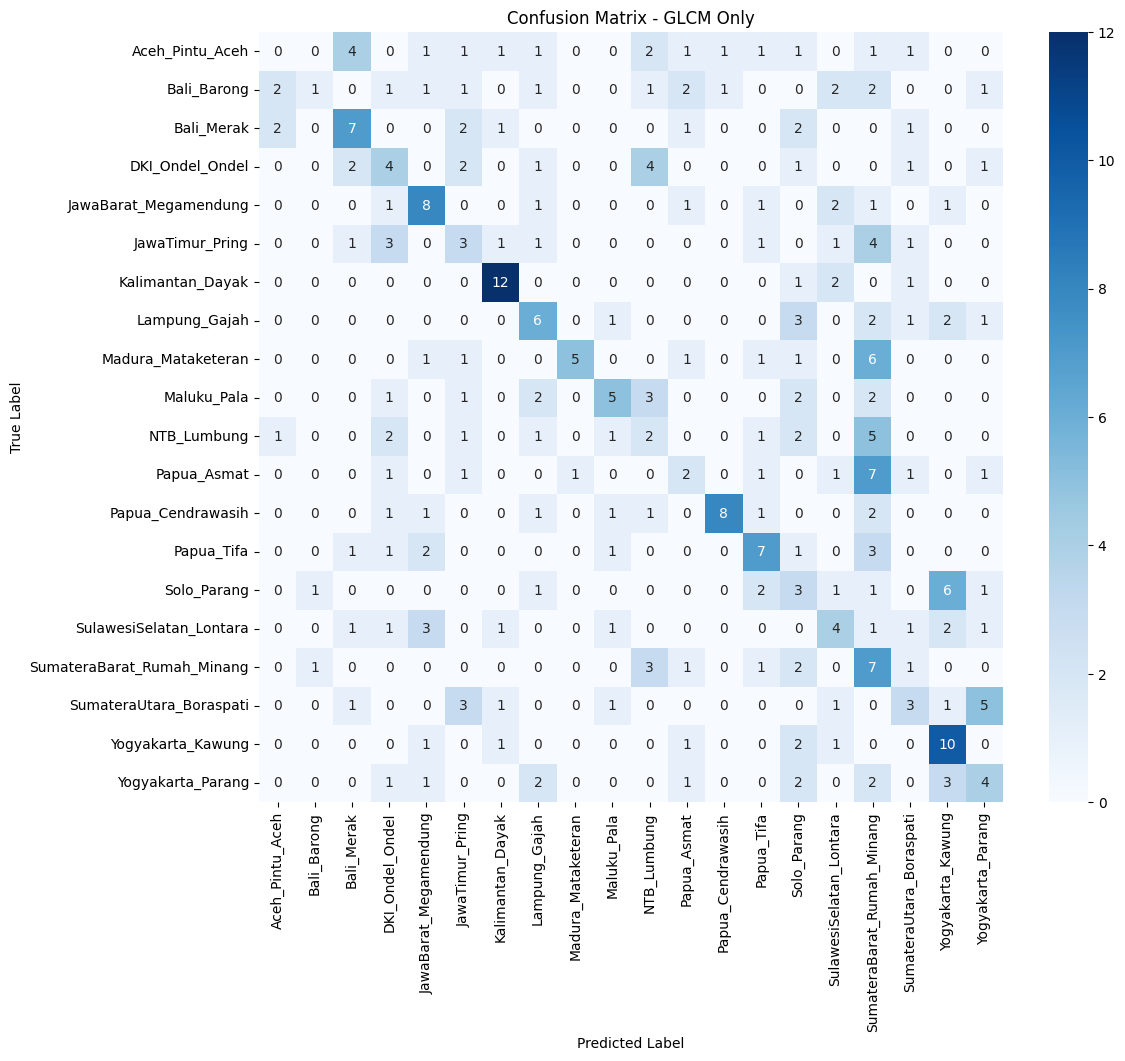

In [5]:
print("Melatih model SVM dengan fitur GLCM saja...")
model = SVC(C=10, kernel='rbf', random_state=42)

start_time = time.time()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
end_time = time.time()

acc = accuracy_score(y_test, y_pred)
print(f"Akurasi: {acc * 100:.2f}%")
print(f"Waktu Eksekusi: {end_time - start_time:.2f} detik")

print("\n--- Classification Report (GLCM Only) ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - GLCM Only')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.show()
